# Customer Churn Analysis — Telecom Dataset
 
Pipeline: Data Preparation → EDA → Feature Engineering → ML Model Training & Comparison → Churn Probability Scoring.

## 1. Import Libraries

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.offline as po
import plotly.graph_objs as go
get_ipython().run_line_magic('matplotlib', 'inline')

## 2. Data Loading & Preparation

In [5]:
# Update the path below to match your local file
churn_dataset = pd.read_csv('churn.csv')
print(f"Dataset shape: {churn_dataset.shape}")

Dataset shape: (7043, 21)


In [6]:
# Replace blank spaces in TotalCharges with NaN, then drop and convert

churn_dataset['TotalCharges'] = churn_dataset['TotalCharges'].replace(' ', np.nan)
churn_dataset = churn_dataset[churn_dataset['TotalCharges'].notnull()].reset_index(drop=True)
churn_dataset['TotalCharges'] = churn_dataset['TotalCharges'].astype(float)


churn_dataset['Churn'] = churn_dataset['Churn'].map({'No': 0, 'Yes': 1})

print("Cleaned dataset shape:", churn_dataset.shape)
print("Churn dtype:", churn_dataset['Churn'].dtype)
churn_dataset.head()

Cleaned dataset shape: (7032, 21)
Churn dtype: int64


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [7]:
churn_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 


In [8]:
# Class distribution
print("Churn distribution:")
print(churn_dataset['Churn'].value_counts())
print(f"\nChurn rate: {churn_dataset['Churn'].mean():.1%}")

Churn distribution:
Churn
0    5163
1    1869
Name: count, dtype: int64

Churn rate: 26.6%


In [9]:
# Check for duplicates
print("Duplicate rows:", churn_dataset.duplicated().sum())

Duplicate rows: 0


In [10]:
churn_dataset.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn
count,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441,0.265785
std,0.368844,24.545260,30.085974,2266.771362,0.441782
min,0.000000,1.000000,18.250000,18.800000,0.000000
25%,0.000000,9.000000,35.587500,401.450000,0.000000
50%,0.000000,29.000000,70.350000,1397.475000,0.000000
75%,0.000000,55.000000,89.862500,3794.737500,1.000000
max,1.000000,72.000000,118.750000,8684.800000,1.000000


## 3. Exploratory Data Analysis (EDA)

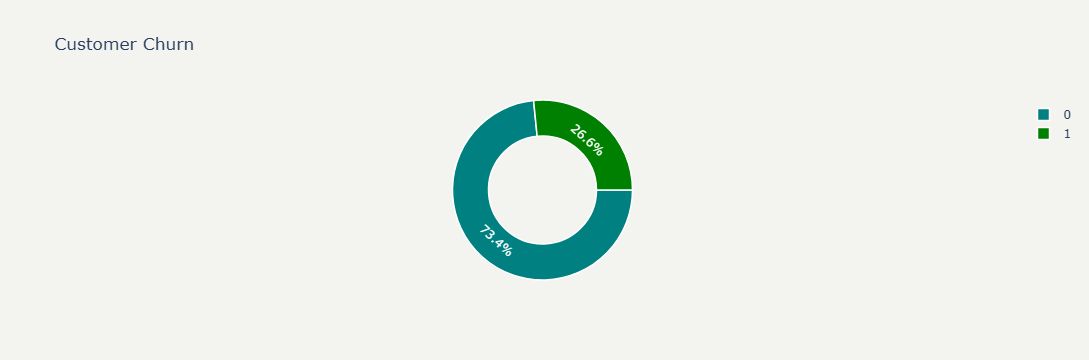

In [14]:
# Exploratory Data Analysis (EDA)
# Visualize Total Customer Churn
plot_by_churn_labels = churn_dataset["Churn"].value_counts().keys().tolist()
plot_by_churn_values = churn_dataset["Churn"].value_counts().values.tolist()

plot_data= [
    go.Pie(labels = plot_by_churn_labels,
           values = plot_by_churn_values,
           marker = dict(colors =  [ 'Teal' ,'Green'],
                         line = dict(color = "white",
                                     width =  1.5)),
           rotation = 90,
           hoverinfo = "label+value+text",
           hole = .6)
]
plot_layout = go.Layout(dict(title = "Customer Churn",
                   plot_bgcolor  = "rgb(243,243,240)",
                   paper_bgcolor = "rgb(243,243,240)",))


fig = go.Figure(data=plot_data, layout=plot_layout)
po.iplot(fig)


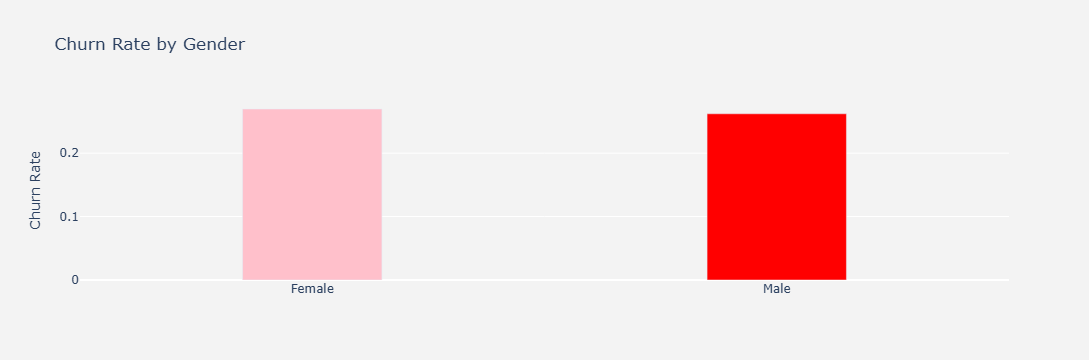

In [19]:
# Visualize Churn Rate by Gender
plot_by_gender = churn_dataset.groupby('gender').Churn.mean().reset_index()
plot_data = [
    go.Bar(
        x=plot_by_gender['gender'],
        y=plot_by_gender['Churn'],
        width = [0.3, 0.3],
        marker=dict(
        color=['pink', 'red'])
    )
]
plot_layout = go.Layout(
        xaxis={"type": "category"},
        yaxis={"title": "Churn Rate"},
        title='Churn Rate by Gender',
        plot_bgcolor  = 'rgb(243,243,243)',
        paper_bgcolor  = 'rgb(243,243,243)',
    )
fig = go.Figure(data=plot_data, layout=plot_layout)
po.iplot(fig)

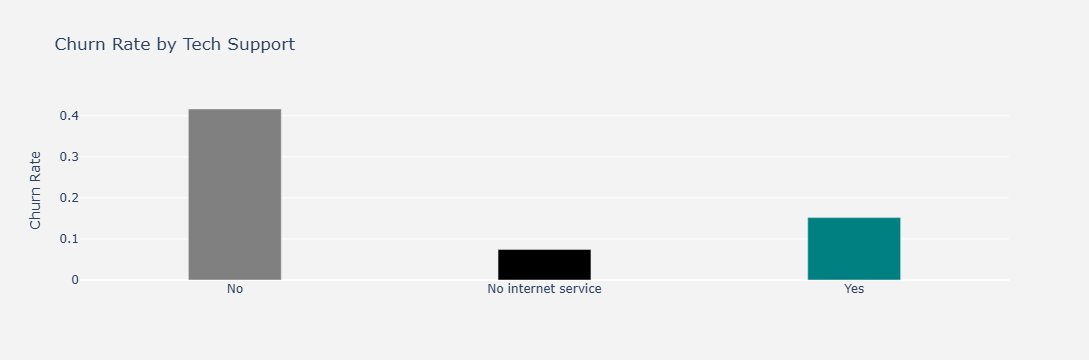

In [22]:
# Visualize Churn Rate by Tech Support
plot_by_techsupport = churn_dataset.groupby('TechSupport').Churn.mean().reset_index()
plot_data = [
    go.Bar(
        x=plot_by_techsupport['TechSupport'],
        y=plot_by_techsupport['Churn'],
        width = [0.3, 0.3, 0.3],
        marker=dict(
        color=['gray', 'black', 'teal'])
    )
]
plot_layout = go.Layout(
        xaxis={"type": "category"},
        yaxis={"title": "Churn Rate"},
        title='Churn Rate by Tech Support',
        plot_bgcolor  = 'rgb(243,243,243)',
        paper_bgcolor  = 'rgb(243,243,243)',
    )
fig = go.Figure(data=plot_data, layout=plot_layout)
po.iplot(fig)

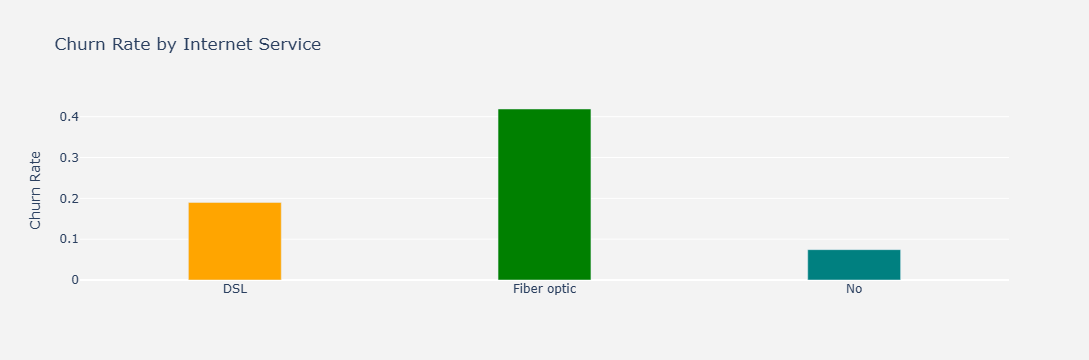

In [23]:
# Visualize Churn Rate by Internet Services
plot_by_internet_service = churn_dataset.groupby('InternetService').Churn.mean().reset_index()
plot_data = [
    go.Bar(
        x=plot_by_internet_service['InternetService'],
        y=plot_by_internet_service['Churn'],
        width = [0.3, 0.3, 0.3],
        marker=dict(
        color=['orange', 'green', 'teal'])
    )
]
plot_layout = go.Layout(
        xaxis={"type": "category"},
        yaxis={"title": "Churn Rate"},
        title='Churn Rate by Internet Service',
        plot_bgcolor  = 'rgb(243,243,243)',
        paper_bgcolor  = 'rgb(243,243,243)',
    )
fig = go.Figure(data=plot_data, layout=plot_layout)
po.iplot(fig)

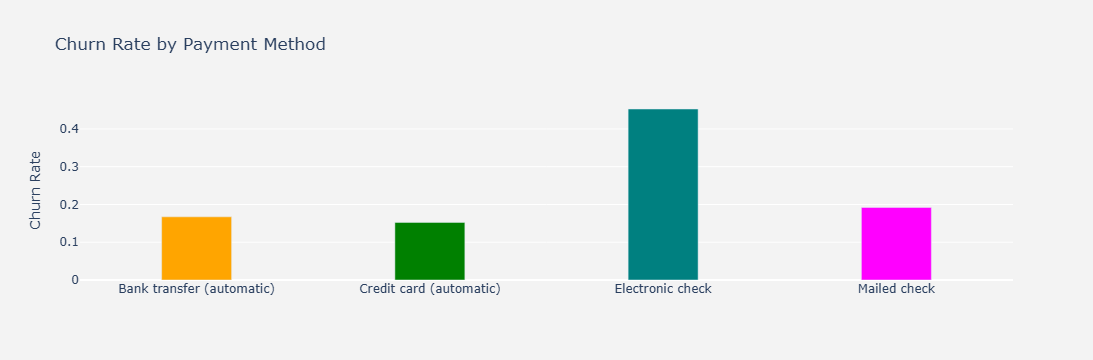

In [24]:
# Visualize Churn Rate by Payment Method
plot_by_payment = churn_dataset.groupby('PaymentMethod').Churn.mean().reset_index()
plot_data = [
    go.Bar(
        x=plot_by_payment['PaymentMethod'],
        y=plot_by_payment['Churn'],
        width = [0.3, 0.3,0.3,0.3],
        marker=dict(
        color=['orange', 'green','teal','magenta'])
    )
]
plot_layout = go.Layout(
        xaxis={"type": "category"},
        yaxis={"title": "Churn Rate"},
        title='Churn Rate by Payment Method',
        plot_bgcolor  = 'rgb(243,243,243)',
        paper_bgcolor  = 'rgb(243,243,243)',
    )
fig = go.Figure(data=plot_data, layout=plot_layout)
po.iplot(fig)


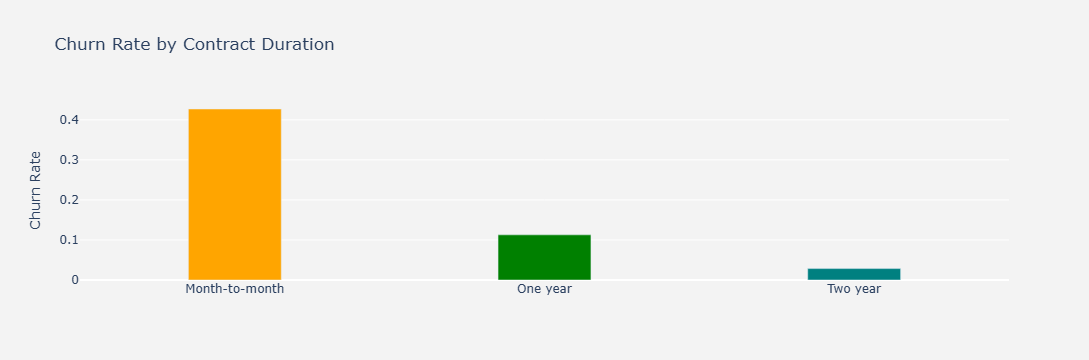

In [25]:
# Visualize Churn Rate by Contract Duration
plot_by_contract = churn_dataset.groupby('Contract').Churn.mean().reset_index()
plot_data = [
    go.Bar(
        x=plot_by_contract['Contract'],
        y=plot_by_contract['Churn'],
        width = [0.3, 0.3,0.3],
        marker=dict(
        color=['orange', 'green','teal'])
    )
]
plot_layout = go.Layout(
        xaxis={"type": "category"},
        yaxis={"title": "Churn Rate"},
        title='Churn Rate by Contract Duration',
        plot_bgcolor  = 'rgb(243,243,243)',
        paper_bgcolor  = 'rgb(243,243,243)',
    )
fig = go.Figure(data=plot_data, layout=plot_layout)
po.iplot(fig)

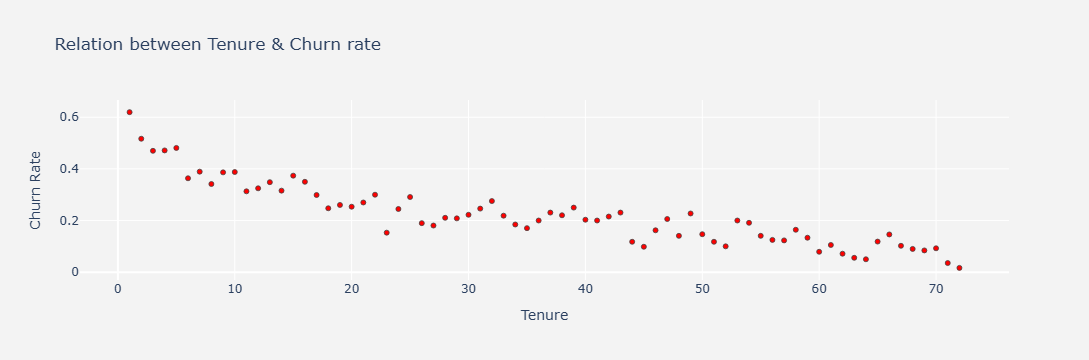

In [27]:
# Visualize Relation between Tenure & Churn rate
plot_by_tenure = churn_dataset.groupby('tenure').Churn.mean().reset_index()
plot_data = [
    go.Scatter(
        x=plot_by_tenure['tenure'],
        y=plot_by_tenure['Churn'],
        mode='markers',
        name='Low',
        marker= dict(size= 5,
            line= dict(width=0.8),
            color= 'red'
           ),
    )
]
plot_layout = go.Layout(
        yaxis= {'title': "Churn Rate"},
        xaxis= {'title': "Tenure"},
        title='Relation between Tenure & Churn rate',
        plot_bgcolor  = "rgb(243,243,243)",
        paper_bgcolor  = "rgb(243,243,243)",
    )
fig = go.Figure(data=plot_data, layout=plot_layout)
po.iplot(fig)


In [30]:
churn_dataset.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,-1.280248,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,-1.161694,-0.994194,0
1,5575-GNVDE,Male,0,No,No,0.064303,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,-0.260878,-0.173740,0
2,3668-QPYBK,Male,0,No,No,-1.239504,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,-0.363923,-0.959649,1
3,7795-CFOCW,Male,0,No,No,0.512486,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),-0.747850,-0.195248,0
4,9237-HQITU,Female,0,No,No,-1.239504,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,0.196178,-0.940457,1


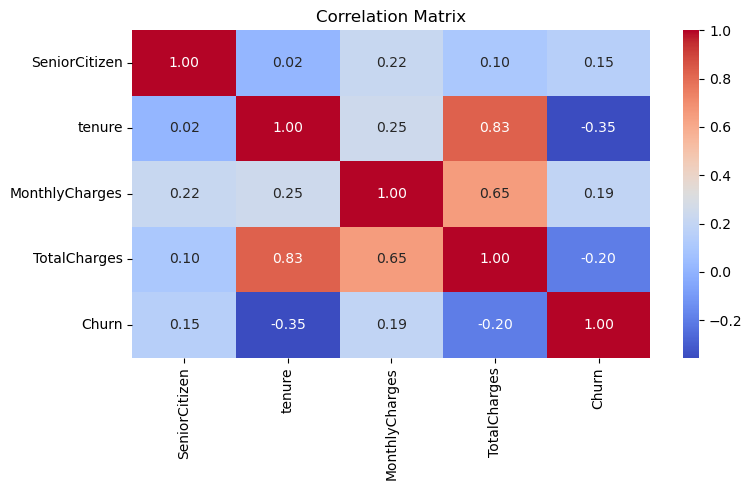

In [41]:
# Correlation heatmap (numeric features)
plt.figure(figsize=(8,5))
sns.heatmap(churn_dataset.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

## 4. Feature Engineering

In [42]:
# FIX: Original notebook had a stray cell (cell 17-18) that re-split the data
# using TotalCharges as the target (regression split) — completely wrong.
# That cell has been removed. Correct target is 'Churn'.

# One-hot encode categorical columns
cat_cols = ['Contract','Dependents','DeviceProtection','gender','InternetService',
            'MultipleLines','OnlineBackup','OnlineSecurity','PaperlessBilling',
            'Partner','PaymentMethod','PhoneService','SeniorCitizen',
            'StreamingMovies','StreamingTV','TechSupport']

churn_encoded = pd.get_dummies(churn_dataset, columns=cat_cols, drop_first=True)
print("Encoded shape:", churn_encoded.shape)

Encoded shape: (7032, 32)


In [43]:
# Scale numeric features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
churn_encoded[num_cols] = scaler.fit_transform(churn_encoded[num_cols])

churn_encoded.head()

,customerID,tenure,MonthlyCharges,TotalCharges,Churn,Contract_One year,Contract_Two year,Dependents_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,...,PaymentMethod_Electronic check,PaymentMethod_Mailed check,PhoneService_Yes,SeniorCitizen_1,StreamingMovies_No internet service,StreamingMovies_Yes,StreamingTV_No internet service,StreamingTV_Yes,TechSupport_No internet service,TechSupport_Yes
0,7590-VHVEG,-1.280248,-1.161694,-0.994194,0,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
1,5575-GNVDE,0.064303,-0.260878,-0.173740,0,True,False,False,False,True,...,False,True,True,False,False,False,False,False,False,False
2,3668-QPYBK,-1.239504,-0.363923,-0.959649,1,False,False,False,False,False,...,False,True,True,False,False,False,False,False,False,False
3,7795-CFOCW,0.512486,-0.747850,-0.195248,0,True,False,False,False,True,...,False,False,False,False,False,False,False,False,False,True
4,9237-HQITU,-1.239504,0.196178,-0.940457,1,False,False,False,False,False,...,True,False,True,False,False,False,False,False,False,False


In [45]:
print("Final columns:", list(churn_encoded.columns))

Final columns: ['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn', 'Contract_One year', 'Contract_Two year', 'Dependents_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'gender_Male', 'InternetService_Fiber optic', 'InternetService_No', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'PaperlessBilling_Yes', 'Partner_Yes', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check', 'PhoneService_Yes', 'SeniorCitizen_1', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'TechSupport_No internet service', 'TechSupport_Yes']


## 5. Model Training & Evaluation

In [46]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics

y = churn_encoded['Churn'].astype(int)   # ensure integer dtype
X = churn_encoded.drop(['Churn', 'customerID'], axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=50)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"y dtype: {y.dtype}, unique values: {y.unique()}")

Train: (4922, 30), Test: (2110, 30)
y dtype: int64, unique values: [0 1]


In [47]:
# Logistic Regression
logmodel = LogisticRegression(random_state=50, max_iter=1000)
logmodel.fit(X_train, y_train)
pred = logmodel.predict(X_test)
logmodel_accuracy = round(metrics.accuracy_score(y_test, pred) * 100, 2)
print(f"Logistic Regression Accuracy: {logmodel_accuracy}%")

Logistic Regression Accuracy: 81.14%


In [48]:
# K-Nearest Neighbors
knnmodel = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2)
knnmodel.fit(X_train, y_train)
knn_pred = knnmodel.predict(X_test)
knn_accuracy = round(metrics.accuracy_score(y_test, knn_pred) * 100, 2)
print(f"KNN Accuracy: {knn_accuracy}%")

KNN Accuracy: 76.82%


In [49]:
# Decision Tree
dtmodel = DecisionTreeClassifier(criterion='gini', random_state=50)
dtmodel.fit(X_train, y_train)
dt_pred = dtmodel.predict(X_test)
dt_accuracy = round(metrics.accuracy_score(y_test, dt_pred) * 100, 2)
print(f"Decision Tree Accuracy: {dt_accuracy}%")

Decision Tree Accuracy: 73.46%


In [50]:
# Random Forest
rfmodel = RandomForestClassifier(n_estimators=100, criterion='entropy', random_state=0)
rfmodel.fit(X_train, y_train)
rf_pred = rfmodel.predict(X_test)
rf_accuracy = round(metrics.accuracy_score(y_test, rf_pred) * 100, 2)
print(f"Random Forest Accuracy: {rf_accuracy}%")

Random Forest Accuracy: 79.62%


In [51]:
svc_accuracy = None  # placeholder

## 6. Model Comparison

In [52]:
model_results = {
    'Logistic Regression': logmodel_accuracy,
    'K-Nearest Neighbor': knn_accuracy,
    'Decision Tree': dt_accuracy,
    'Random Forest': rf_accuracy,
}

Model_Comparison_df = (pd.DataFrame(list(model_results.items()), columns=['Model', 'Score'])
                       .sort_values(by='Score', ascending=False)
                       .reset_index(drop=True))
Model_Comparison_df

,Model,Score
0,Logistic Regression,81.14
1,Random Forest,79.62
2,K-Nearest Neighbor,76.82
3,Decision Tree,73.46


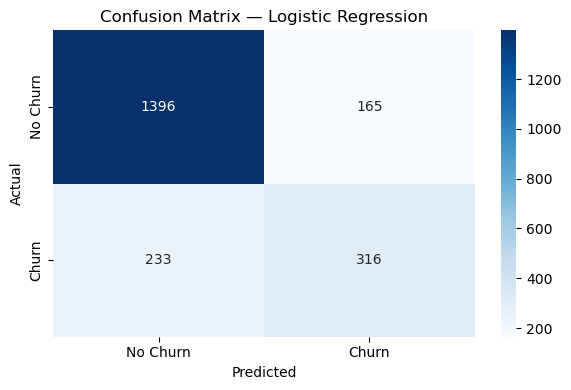


Classification Report:
              precision    recall  f1-score   support

    No Churn       0.86      0.89      0.88      1561
       Churn       0.66      0.58      0.61       549

    accuracy                           0.81      2110
   macro avg       0.76      0.73      0.74      2110
weighted avg       0.80      0.81      0.81      2110



In [53]:
# Confusion matrix for best model (Logistic Regression)
from sklearn.metrics import confusion_matrix, classification_report

conf_mat = confusion_matrix(y_test, pred)

plt.figure(figsize=(6,4))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn','Churn'], yticklabels=['No Churn','Churn'])
plt.title('Confusion Matrix — Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, pred, target_names=['No Churn','Churn']))

## 7. Churn Probability Scoring

In [54]:
# join back to the original customer IDs.

feature_cols = X_test.columns  # same feature set as training
all_X = churn_encoded.drop(['Churn', 'customerID'], axis=1)

churn_proba = pd.DataFrame({
    'customerID': churn_dataset['customerID'],
    'Probability_of_Churn': logmodel.predict_proba(all_X)[:, 1]
})

churn_proba = churn_proba.sort_values('Probability_of_Churn', ascending=False).reset_index(drop=True)
print("Top 10 customers most likely to churn:")
churn_proba.head(10)

Top 10 customers most likely to churn:


,customerID,Probability_of_Churn
0,9497-QCMMS,0.845913
1,9300-AGZNL,0.845468
2,5178-LMXOP,0.842910
3,4424-TKOPW,0.842187
4,2720-WGKHP,0.841340
5,5150-ITWWB,0.839300
6,5567-WSELE,0.835429
7,7024-OHCCK,0.833884
8,7216-EWTRS,0.830137
9,1374-DMZUI,0.828381
